# Assignment 4

### <span style="color:chocolate"> Submission requirements </span>

Your work will not be graded if your notebook doesn't include output. In other words, <span style="color:red"> make sure to rerun your notebook before submitting to Gradescope </span> (Note: if you are using Google Colab: go to Edit > Notebook Settings  and uncheck Omit code cell output when saving this notebook, otherwise the output is not printed).

Additional points may be deducted if these requirements are not met:

    
* Comment your code;
* Each graph should have a title, labels for each axis, and (if needed) a legend. Each graph should be understandable on its own;
* Try and minimize the use of the global namespace (meaning, keep things inside functions).
---

### Import libraries

In [1]:
%pip install tensorflow
%pip install "numpy<2"

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns  # for nicer plots
sns.set(style="darkgrid")  # default style

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from keras import metrics
from keras.datasets import fashion_mnist

tf.get_logger().setLevel('ERROR')

/opt/conda/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
2026-02-08 12:30:15.681275: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-08 12:30:15.744950: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-08 12:30:17.325557: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


---
### Step 1: Data ingestion

You'll train a binary classifier using the [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist) dataset. This consists of 70,000 grayscale images (28x28). Each image is associated with 1 of 10 classes. The dataset was split by the creators; there are 60,000 training images and 10,000 test images. Note also that Tensorflow includes a growing [library of datasets](https://www.tensorflow.org/datasets/catalog/overview) and makes it easy to load them in numpy arrays.

In [3]:
# Load the Fashion MNIST dataset.
(X_train, Y_train), (X_test, Y_test) = fashion_mnist.load_data()

---
### Step 2: Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) and Data Preprocessing are often iterative processes that involve going back and forth to refine and improve the quality of data analysis and preparation. However, the specific order can vary depending on the project's requirements. In some cases, starting with EDA, as you see in this assignment, could be more useful, but there is no rigid rule dictating the sequence in all situations.

### <span style="color:chocolate">Exercise 1:</span> Getting to know your data (5 points)

Complete the following tasks:

1. Print the shapes and types of (X_train, Y_train) and (X_test, Y_test). Interpret the shapes (i.e., what do the numbers represent?). Hint: For types use the <span style="color:chocolate">type()</span> function.
2. Define a list of strings of class names corresponding to each class in (Y_train, Y_test). Call this list label_names. Hint: Refer to the Fashion MNIST documentation.

In [4]:
print("Shapes:")
print(f"{X_train.shape=}")
print(f"{Y_train.shape=}")
print(f"{X_test.shape=}")
print(f"{Y_test.shape=}")

print("\nTypes:")
print(f"{type(X_train[0])=}")
print(f"{X_train.dtype=}")
print("\n")
print(f"{type(Y_train[0])=}")
print(f"{Y_train.dtype=}")
print("\n")
print(f"{type(X_test[0])=}")
print(f"{X_test.dtype=}")
print("\n")
print(f"{type(Y_test[0])=}")
print(f"{Y_test.dtype=}")

Shapes:
X_train.shape=(60000, 28, 28)
Y_train.shape=(60000,)
X_test.shape=(10000, 28, 28)
Y_test.shape=(10000,)

Types:
type(X_train[0])=<class 'numpy.ndarray'>
X_train.dtype=dtype('uint8')


type(Y_train[0])=<class 'numpy.uint8'>
Y_train.dtype=dtype('uint8')


type(X_test[0])=<class 'numpy.ndarray'>
X_test.dtype=dtype('uint8')


type(Y_test[0])=<class 'numpy.uint8'>
Y_test.dtype=dtype('uint8')


**Answer 1**

The shape of `X_train` and `X_test` tell us that we have a numpy array of nested arrays of size 28x28. Inside the arrays are 8 bit integers, meaning this looks like image data.
There are 60,000 observations in the train set and 10,000 in the test set.
           
`Y_train` and `Y_test` have a single integer digit per observation, which corresponds to a specific class code for each image.

In [5]:
label_names =["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
print(label_names)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


### <span style="color:chocolate">Exercise 2:</span> Getting to know your data - cont'd (5 points)

Fashion MNIST images have one of 10 possible labels (shown above). 

Complete the following tasks:

1. Display the first 5 images in X_train for each class in Y_train, arranged in a 10x5 grid. Use the label_names list defined above;
2. Determine the minimum and maximum pixel values for images in the X_train dataset.


In [6]:
display_images = [[] for _ in range(10)]

for label_index,  label in enumerate(label_names):
    target = 5
    for image_index in range(len(Y_train)):
        if target < 1:
            break
        if Y_train[image_index] == label_index:
            display_images[label_index].append(X_train[image_index])
            target -= 1

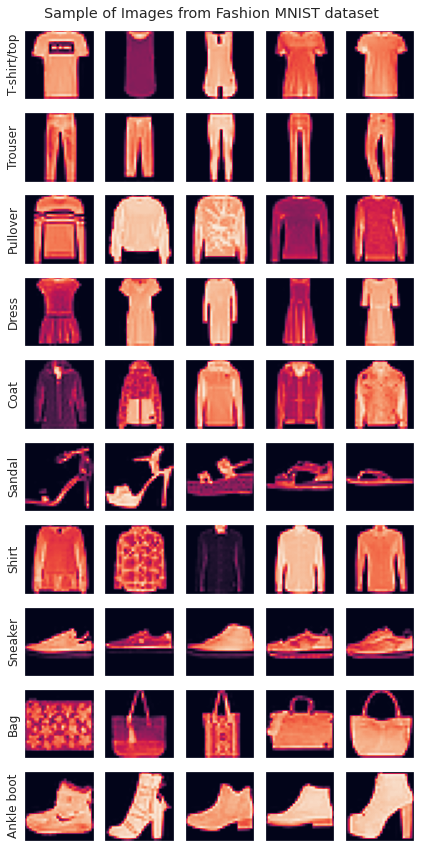

In [7]:
fig, axes = plt.subplots(10, 5, figsize=(6, 12))

for label_index, label_images in enumerate(display_images):
    for image_index in range(5):
        ax = axes[label_index, image_index]
        ax.imshow(label_images[image_index])
        ax.get_xaxis().set_visible(False)
        ax.set_yticks([])
for ax, row in zip(axes[:,0], label_names):
    ax.set_ylabel(row, size=12)
fig.suptitle("Sample of Images from Fashion MNIST dataset")
plt.tight_layout(pad=1.08, h_pad=None, w_pad=None, rect=None)
plt.show()

In [8]:
x_min = X_train.min()
x_max = X_train.max()
print("\nMinimum and maximum values in X_train")
print(f"{x_min=}")
print(f"{x_max=}")


Minimum and maximum values in X_train
x_min=0
x_max=255


**Answer:**

The minimum value in the data is 0 and the maximum value is 255.

---
### Step 3: Data preprocessing

This step is essential for preparing this image data in a format that is suitable for ML algorithms. 

### <span style="color:chocolate">Exercise 3:</span> Feature preprocessing (5 points)

In the previous lab, the input data had just a few features. Here, we treat **every pixel value as a separate feature**, so each input example has 28x28 (784) features!

In this exercise, you'll perform the following tasks:

1. Normalize the pixel values in both X_train and X_test data so they range between 0 and 1;
2. For each image in X_train and X_test, flatten the 2-D 28x28 pixel array to a 1-D array of size 784. Hint: use the <span style="color:chocolate">reshape()</span> method available in NumPy. Note that by doing so you will overwrite the original arrays;
3. Pint the shape of X_train and X_test arrays.

In [9]:
# 1. Normalize X data

X_train = (X_train - x_min) / (x_max - x_min)
X_test  = (X_test - x_min) / (x_max - x_min)

In [10]:
print(f"{X_train.max()=}")
print(f"{X_train.min()=}")

X_train.max()=1.0
X_train.min()=0.0


In [11]:
# 2. Flatten
X_train = X_train.reshape(len(X_train), 784)
X_test = X_test.reshape(len(X_test), 784)

In [12]:
# 3. Print the shape

print(f"{X_train.shape=}")
print(f"{X_test.shape=}")

X_train.shape=(60000, 784)
X_test.shape=(10000, 784)


### <span style="color:chocolate">Exercise 4:</span> Label preprocessing (5 points)

This assignment involves binary classification. Specifically, the objective is to predict whether an image belongs to the sneaker class (class 7) or not.

Therefore, write code so that for each example in (Y_train, Y_test), the outcome variable is represented as follows: 
* $y=1$, for sneaker class (positive examples), and
* $y=0$, for non-sneaker class (negative examples).

Note: To avoid "ValueError: assignment destination is read-only", first create a copy of the (Y_train, Y_test) data and call the resulting arrays (Y_train, Y_test). Then overwrite the (Y_train, Y_test) arrays to create binary outcomes.

In [13]:
# # Make copies of the original dataset for binary classification task.
o_X_train = X_train
o_X_test = X_test
o_Y_train = Y_train
o_Y_test = Y_test

In [14]:
# use the original data
Y_train = np.copy(o_Y_train)
Y_test = np.copy(o_Y_test)

In [15]:
# Transform the Y values to 1 (Sneakers), 0 (Non-sneakers)
sneaker_code = 7
Y_train = (Y_train == sneaker_code).astype(int)
Y_test = (Y_test == sneaker_code).astype(int)

In [16]:
print(f"Sneakers in train set = {sum(Y_train)}")
print(f"Sneakers in test set = {sum(Y_test)}")

Sneakers in train set = 6000
Sneakers in test set = 1000


### <span style="color:chocolate">Exercise 5:</span> Data splits (10 points)

Using the <span style="color:chocolate">train_test_split()</span> method available in scikit-learn:
1. Retain 20% from the training data for validation purposes. Set random state to 1234. All the other arguments of the method are set to default values. Name the resulting dataframes as follows: X_train_mini, X_val, Y_train_mini, Y_val.
2. Print the shape of each array.

In [17]:
X_train_mini, X_val, Y_train_mini, Y_val = train_test_split(X_train, Y_train, test_size=0.2, random_state=1234)

In [18]:
print(f"{X_train_mini.shape=}")
print(f"{Y_train_mini.shape=}")
print(f"{X_val.shape=}")
print(f"{Y_val.shape=}")

X_train_mini.shape=(48000, 784)
Y_train_mini.shape=(48000,)
X_val.shape=(12000, 784)
Y_val.shape=(12000,)


### <span style="color:chocolate">Exercise 6:</span> Data shuffling (10 points)

Since you'll be using Batch Gradient Descent (BGD) for training, it is important that **each batch is a random sample of the data** so that the gradient computed is representative. 

1. Use integer array indexing to re-order (X_train_mini, Y_train_mini) using a list of shuffled indices. In doing so, you will overwrite the arrays.

In [19]:
np.random.seed(0)
shuffle = np.random.permutation(np.arange(X_train_mini.shape[0]))
X_train_mini, Y_train_mini = X_train_mini[shuffle], Y_train_mini[shuffle]

---
### Step 4: Exploratory Data Analysis (EDA) - cont'd

Before delving into model training, let's further explore the raw feature values by comparing sneaker and non-sneaker training images.

### <span style="color:chocolate">Exercise 7:</span> Pixel distributions (10 points)

1. Identify all sneaker images in X_train_mini and calculate the mean pixel value for each sneaker image. Visualize these pixel values using a histogram. Print the mean pixel value across all sneaker images.
2. Identify all non-sneaker images in X_train_mini and calculate the mean pixel value for each non-sneaker image. Visualize these pixel values using a histogram. Print the mean pixel value across all non-sneaker images.
3. Based on the histogram results, assess whether there is any evidence suggesting that pixel values can be utilized to distinguish between sneaker and non-sneaker images. Justify your response.

Notes: Make sure to provide a descriptive title and axis labels for each histogran. Make sure you utilize Y_train_mini to locate the sneaker and non-sneaker class.

### Exercise 7: Part 1

In [20]:
# 1. Mean pixel value for sneakers with histogram plot
X_train_mini_sneakers = X_train_mini[Y_train_mini == 1]

# mean pixel value of each image
X_train_mini_sneakers_means = X_train_mini_sneakers.mean(axis=1)

# mean pixel value across all images
X_train_mini_all_sneakers_mean = X_train_mini_sneakers.mean()
print(f"Mean value of pixels for all sneakers = {X_train_mini_all_sneakers_mean}")

Mean value of pixels for all sneakers = 0.16827472759937295


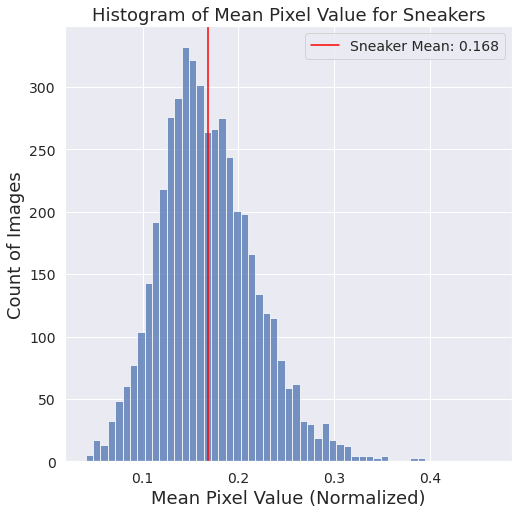

In [21]:
plt.figure(figsize=(8, 8))
sns.histplot(X_train_mini_sneakers_means)
plt.xlabel("Mean Pixel Value (Normalized)", size=18)
plt.ylabel("Count of Images", size=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title("Histogram of Mean Pixel Value for Sneakers", size=18)
plt.axvline(x=X_train_mini_all_sneakers_mean, color='red', label=f'Sneaker Mean: {X_train_mini_all_sneakers_mean:.3f}')
plt.legend(fontsize=14)
plt.show()

### Exercise 7: Part 2

In [22]:
# 2. Mean pixel value for NON-sneakers images with histogram plot
X_train_mini_non_sneakers = X_train_mini[Y_train_mini == 0]

# mean pixel value of each image
X_train_mini_non_sneakers_means = X_train_mini_non_sneakers.mean(axis=1)

# mean pixel value across all images
X_train_mini_all_non_sneakers_mean = X_train_mini_non_sneakers.mean()
print(f"Mean value of pixels for all non-sneakers = {X_train_mini_all_non_sneakers_mean}")

Mean value of pixels for all non-sneakers = 0.29900192681239074


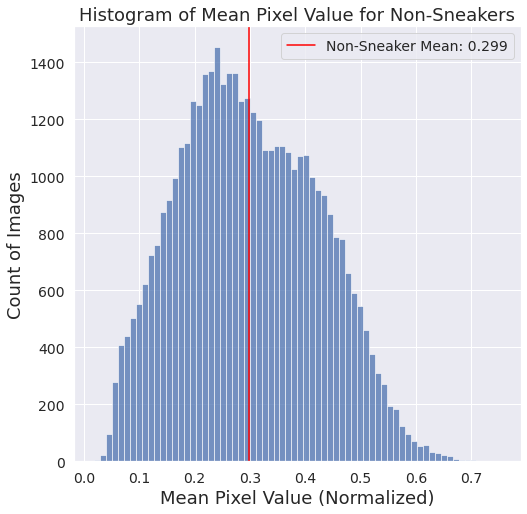

In [23]:
plt.figure(figsize=(8, 8))
sns.histplot(X_train_mini_non_sneakers_means)
plt.xlabel("Mean Pixel Value (Normalized)", size=18)
plt.ylabel("Count of Images", size=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title("Histogram of Mean Pixel Value for Non-Sneakers", size=18)
plt.axvline(x=X_train_mini_all_non_sneakers_mean, color='red', label=f'Non-Sneaker Mean: {X_train_mini_all_non_sneakers_mean:.3f}')
plt.legend(fontsize=14)
plt.show()

In [24]:
from scipy import stats
t_stat, p_value = stats.ttest_ind(X_train_mini_sneakers_means, X_train_mini_non_sneakers_means,
                                  nan_policy='omit', equal_var=False)
print("T Test of Mean Pixel Value of Sneaker and Non-Sneaker Images")
print(f"t-stat = {t_stat}, p-value = {p_value}")

T Test of Mean Pixel Value of Sneaker and Non-Sneaker Images
t-stat = -138.5101791227245, p-value = 0.0


In [25]:
print(f"Out of {X_train_mini_sneakers_means.size} sneaker images, only {sum(X_train_mini_sneakers_means >= X_train_mini_all_non_sneakers_mean)} are greater than or equal to the mean of the non-sneaker images.")

Out of 4800 sneaker images, only 61 are greater than or equal to the mean of the non-sneaker images.


### Exercise 7: Part 3

Based on the histogram results, assess whether there is any evidence suggesting that pixel values can be utilized to distinguish between sneaker and non-sneaker images. Justify your response.

**Answer:**

The mean pixel value of sneakers is 0.168, and the mean pixel value of non-sneakers is 0.299. Out of 4800 sneaker images, only 61 are greater than or equal to the mean of the non-sneaker images. A t-test of the difference in means returns a t-statistic of -138. This tells us the distributions of sneakers and non-sneakers are significantly different.

---
### Step 4: Modeling

### <span style="color:chocolate">Exercise 8:</span> Baseline model (10 points)

When dealing with classification problems, a simple baseline is to select the *majority* class (the most common label in the training set) and use it as the prediction for all inputs.

With this information in mind:

1. What is the number of sneaker images in Y_train_mini? Print out your answer.
2. What is the number of non-sneaker images in Y_train_mini? Print out your answer.
3. What is the majority class in Y_train_mini? Print out your answer.
4. What is the accuracy of a majority class classifier for Y_train_mini? Print out your answer.
5. Implement a function that computes the Log Loss (binary cross-entropy) metric and use it to evaluate this baseline on both the mini train (Y_train_mini) and validation (Y_val) data. Use 0.1 as the predicted probability for your baseline (reflecting what we know about the original distribution of classes in the mini training data). Hint: for additional help, see the file ``04 Logistic Regression with Tensorflow_helper.ipynb``; You should use **np.log()** when implementing the log loss function.

In [26]:
Y_train_mini_sneakers = sum(Y_train_mini == 1)
Y_train_mini_non_sneakers = sum(Y_train_mini != 1)

print(f"1. {Y_train_mini_sneakers} sneakers in Y_train_mini")
print(f"2. {Y_train_mini_non_sneakers} non-sneakers in Y_train_mini")
print(f"3. The majority class is non-sneakers with {Y_train_mini_non_sneakers} observations compared to {Y_train_mini_sneakers} sneakers in Y_train_mini")
accuracy = (Y_train_mini_non_sneakers) / Y_train_mini.size
print(f"4. By labeling all images as non-sneaker, the classifier has accuracy of {accuracy}" )

1. 4800 sneakers in Y_train_mini
2. 43200 non-sneakers in Y_train_mini
3. The majority class is non-sneakers with 43200 observations compared to 4800 sneakers in Y_train_mini
4. By labeling all images as non-sneaker, the classifier has accuracy of 0.9


In [27]:
print("5.")

def log_loss(x, y, predicted_probability=0.1):
    log_p = np.log(predicted_probability)
    log_1_p = np.log(1 - predicted_probability)
    return -np.sum(y*log_p + (1 - y)*log_1_p) / x.shape[0]

print(f"Log loss of X_train_mini, Y_train_mini = {log_loss(X_train_mini, Y_train_mini)}")
print(f"Log loss of X_val, Y_val = {log_loss(X_val, Y_val)}")

5.
Log loss of X_train_mini, Y_train_mini = 0.3250829733914482
Log loss of X_val, Y_val = 0.3250829733914482


### <span style="color:chocolate">Exercise 9:</span> Improvement over Baseline with TensorFlow (10 points)

Let's use TensorFlow to train a binary logistic regression model much like you did in the previous assignment. The goal here is to build a ML model to improve over the baseline classifier.

1. Fill in the <span style="color:green">NotImplemented</span> parts of the build_model() function below by following the instructions provided as comments. Hint: the activation function, the loss, and the evaluation metric are different compared to the linear regression model;
2. Build and compile a model using the build_model() function and the (X_train_mini, Y_train_mini) data. Set learning_rate = 0.0001. Call the resulting object *model_tf*.
3. Train *model_tf* using the (X_train_mini, Y_train_mini) data. Set num_epochs = 5 and batch_size=32. Pass the (X_val, Y_val) data for validation. Hint: see the documentation behind the [tf.keras.Model.fit()](https://www.tensorflow.org/api_docs/python/tf/keras/Model) method.
4. Generate a (1,2) plot (for the mini training and validation data). In the subplot at position (1, 1), display the loss values on the y-axis and the epoch number on the x-axis. In the subplot at position (1, 2), display the accuracy values on the y-axis and the epoch number on the x-axis. Hint: check what the [tf.keras.Model.fit()](https://www.tensorflow.org/api_docs/python/tf/keras/Model) method returns.

In [28]:
def build_model(num_features, learning_rate):
  """Build a TF linear regression model using Keras.

  Args:
    num_features: The number of input features.
    learning_rate: The desired learning rate for SGD.

  Returns:
    model: A tf.keras model (graph).
  """
  # This is not strictly necessary, but each time you build a model, TF adds
  # new nodes (rather than overwriting), so the colab session can end up
  # storing lots of copies of the graph when you only care about the most
  # recent. Also, as there is some randomness built into training with SGD,
  # setting a random seed ensures that results are the same on each identical
  # training run.
  tf.keras.backend.clear_session()
  tf.random.set_seed(0)

  # Build a model using keras.Sequential. While this is intended for neural
  # networks (which may have multiple layers), we want just a single layer for
  # binary logistic regression.
  model = tf.keras.Sequential()
  model.add(tf.keras.layers.Dense(
      units=1,        # output dim
      input_shape=(num_features,),  # input dim
      use_bias=True,               # use a bias (intercept) param
      activation="sigmoid",
      kernel_initializer=tf.keras.initializers.Ones(), # initialize params to 1
      bias_initializer=tf.keras.initializers.Ones()    # initialize bias to 1
      )
  )

  # We need to choose an optimizer. We'll use SGD, which is actually mini-batch GD
  optimizer = tf.keras.optimizers.SGD(learning_rate=float(learning_rate))

  # Finally, compile the model. Select the accuracy metric (!!!). This finalizes the graph for training.
  model.compile(
      loss=tf.keras.losses.BinaryCrossentropy(),
      optimizer=optimizer,
      metrics=[tf.keras.metrics.BinaryAccuracy()]
  )
  
  return model

In [29]:
tf.random.set_seed(0)
# 2. Build and compile model
model_tf = build_model(X_train_mini.shape[1], learning_rate=0.0001)


# 3. Fit the model
tf_history = model_tf.fit(x=X_train_mini,
             y=Y_train_mini,
             validation_data=(X_val, Y_val),
             epochs = 5,
             batch_size=32)

/opt/conda/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-02-08 12:30:21.002896: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/5
   1/1500 ━━━━━━━━━━━━━━━━━━━━ 3:52 155ms/step - binary_accuracy: 0.0938 - loss: 198.4385

2026-02-08 12:30:21.169633: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 150528000 exceeds 10% of free system memory.


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - binary_accuracy: 0.1017 - loss: 208.5961 - val_binary_accuracy: 0.1000 - val_loss: 199.9825
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - binary_accuracy: 0.1017 - loss: 196.0804 - val_binary_accuracy: 0.1000 - val_loss: 187.4252
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - binary_accuracy: 0.1017 - loss: 183.5648 - val_binary_accuracy: 0.1000 - val_loss: 174.8679
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - binary_accuracy: 0.1017 - loss: 171.0492 - val_binary_accuracy: 0.1000 - val_loss: 162.3107
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - binary_accuracy: 0.1017 - loss: 158.5334 - val_binary_accuracy: 0.1000 - val_loss: 149.7533


{'binary_accuracy': [0.10000000149011612, 0.10000000149011612, 0.10000000149011612, 0.10000000149011612, 0.10000000149011612], 'loss': [205.61666870117188, 193.0897674560547, 180.56300354003906, 168.0361328125, 155.50917053222656], 'val_binary_accuracy': [0.10000000149011612, 0.10000000149011612, 0.10000000149011612, 0.10000000149011612, 0.10000000149011612], 'val_loss': [199.9825439453125, 187.42523193359375, 174.86793518066406, 162.31069946289062, 149.75328063964844]}


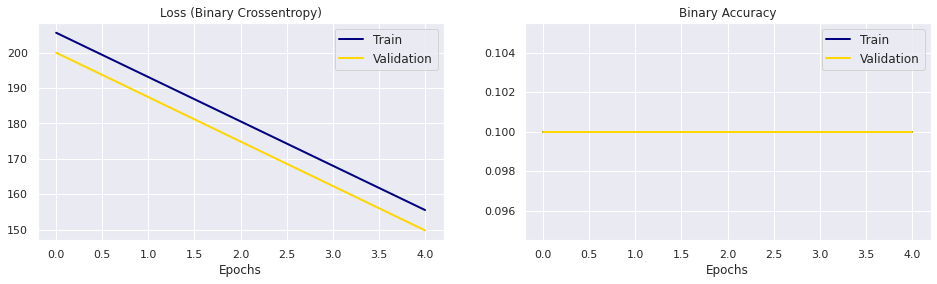

In [30]:
# 4. Generate (1,2) pl


def plot_model_history(history):
    print(history)
    # plot loss for train and validation
    fig = plt.figure(figsize=(16, 4))
    ax = fig.add_subplot(1, 2, 1)
    plt.plot(history['loss'], lw=2, color='navy')
    plt.plot(history['val_loss'], lw=2, color='gold')
    plt.legend(['Train', 'Validation'], fontsize=12)
    ax.set_xlabel('Epochs', size=12)
    ax.set_title('Loss (Binary Crossentropy)');

    # plot accuracy for train and validation
    ax = fig.add_subplot(1, 2, 2)
    plt.plot(history['binary_accuracy'], lw=2, color='navy')
    plt.plot(history['val_binary_accuracy'], lw=2, color='gold')
    plt.legend(['Train', 'Validation'], fontsize=12)
    ax.set_xlabel('Epochs', size=12)
    ax.set_title('Binary Accuracy');

history = tf_history.history
plot_model_history(history)

---
### Step 5: Hyperparameter tuning

Hyperparameter tuning is a crucial step in optimizing ML models. It involves systematically adjusting hyperparameters such as learning rate, number of epochs, and optimizer to find the model configuration that leads to the best generalization performance.

This tuning process is typically conducted by monitoring the model's performance on the validation vs. training set. It's important to note that using the test set for hyperparameter tuning can compromise the integrity of the evaluation process by violating the assumption of "blindness" of the test data.

### <span style="color:chocolate">Exercise 10:</span> Hyperparameter tuning (10 points)

1. Fine-tune the **learning rate** and **number of epochs** hyperparameters of *model_tf* to determine the setup that yields the most optimal generalization performance. Feel free to explore various values for these hyperparameters. Generate a (1, 2) subplot to visualize the training and validation loss on the left, and training and validation accuracy on the right, across all epochs. Hint: you can manually test different hyperparameter values or you can use the [Keras Tuner](https://www.tensorflow.org/tutorials/keras/keras_tuner). If you decide to work with the Keras Tuner, define a new model building function named <span style="color:chocolate">build_model_tuner()</span>.

After identifying your preferred model configuration, print the following information:

2. The first five learned parameters of the model (including the bias term);
3. The final-epoch loss on both the mini training and validation datasets;
4. The difference between the final-epoch training and validation losses;
5. Compare the final-epoch training/validation loss of the TensorFlow model (model_tf) with the baseline model's loss. Does the TensorFlow model demonstrate an improvement over the baseline model?

Please note that we will consider 'optimal model configuration' any last-epoch training and validation loss that is below 0.08.

In [31]:
def build_plot_model(learning_rate=0.0001, epochs=5):
    model = build_model(X_train_mini.shape[1], learning_rate=learning_rate)
    history = model.fit(x=X_train_mini,
             y=Y_train_mini,
             validation_data=(X_val, Y_val),
             epochs = epochs,
             batch_size=32)
    target_loss = 0.08

    plot_model_history(history.history)
    val_loss = history.history['val_loss'][-1]
    print(f"\nValidation loss = {val_loss}")
    if val_loss < target_loss:
        print("\nSUCCESS!")
    else:
        print("\nKeep training...")
        
    return (model, history)

Epoch 1/8
   1/1500 ━━━━━━━━━━━━━━━━━━━━ 3:41 148ms/step - binary_accuracy: 0.0938 - loss: 198.4385

2026-02-08 12:30:39.868001: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 150528000 exceeds 10% of free system memory.


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - binary_accuracy: 0.8894 - loss: 6.3915 - val_binary_accuracy: 0.9717 - val_loss: 0.0777
Epoch 2/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - binary_accuracy: 0.9749 - loss: 0.0745 - val_binary_accuracy: 0.9772 - val_loss: 0.0578
Epoch 3/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - binary_accuracy: 0.9803 - loss: 0.0585 - val_binary_accuracy: 0.9791 - val_loss: 0.0528
Epoch 4/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - binary_accuracy: 0.9820 - loss: 0.0539 - val_binary_accuracy: 0.9800 - val_loss: 0.0507
Epoch 5/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - binary_accuracy: 0.9824 - loss: 0.0518 - val_binary_accuracy: 0.9800 - val_loss: 0.0495
Epoch 6/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - binary_accuracy: 0.9827 - loss: 0.0505 - val_binary_accuracy: 0.9804 - val_loss: 0.0488
Epoch 7/8
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - binary_accuracy: 0.9834 - loss: 0.0496 - val_binary_accuracy: 0.9808 - val_loss: 0.0483
Epoch 8/8

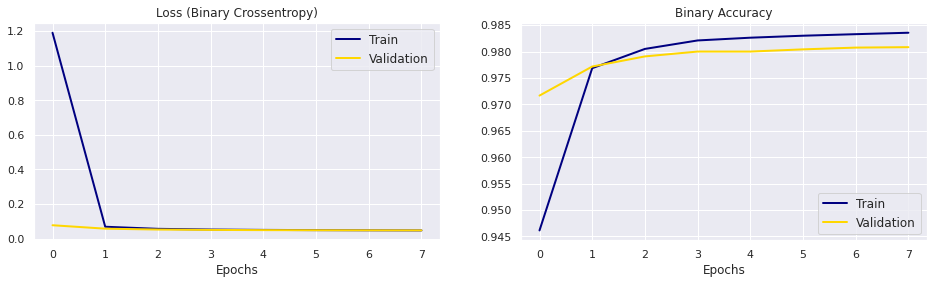

In [32]:
# build_plot_model(0.001, 10)
# build_plot_model(0.01, 10)
# model_tf = build_plot_model(0.02, 10)
model_tf, model_history = build_plot_model(0.2, 8)

In [33]:
print("2.")
weights = model_tf.get_weights()[0]
bias = model_tf.get_weights()[1]
for i in range(0,5):
    print(f"Weight X{i} = {weights[i][0]}")
print(f"Bias = {bias[0]}")

print("\n3.")
model_history.history
train_loss = model_history.history['loss'][-1]
val_loss = model_history.history['val_loss'][-1]
print(f"Training final epoch loss = {train_loss}")
print(f"Validation final epoch loss = {val_loss}")

print("\n4.")
loss_diff = train_loss - val_loss
print(f"Difference between final epoch trainina and validation loss = {loss_diff}")

2.
Weight X0 = 0.9997036457061768
Weight X1 = 0.9989357590675354
Weight X2 = 0.9837827682495117
Weight X3 = 0.9685792922973633
Weight X4 = 0.9350090026855469
Bias = -2.0774788856506348

3.
Training final epoch loss = 0.04776386916637421
Validation final epoch loss = 0.047992315143346786

4.
Difference between final epoch trainina and validation loss = -0.00022844597697257996


**Answer 5:**
The majority classifier baseline had an accuracy of 90% by only labeling non-sneaker, so it had a 0% accuracy on sneaker images. The log loss function returned a value of 0.325 for both the training and validation sets.

The `model_tf` has improved on both accuracy and loss. The final epoch training loss is 0.0477 and validation loss is 0.0480. Accuracy exceeds the 90% baseline with 98.3% for training and 98.1% for validation.


---
### Step 6: Evaluation and Generalization


Now that you've determined the optimal set of hyperparameters, it's time to evaluate your optimized model on the test data to gauge its performance in real-world scenarios, commonly known as inference.

### <span style="color:chocolate">Exercise 11:</span> Computing accuracy (10 points)

1. Calculate aggregate accuracy on both mini train and test datasets using a probability threshold of 0.5. Hint: You can utilize the <span style="color:chocolate">model.evaluate()</span> method provided by tf.keras. Note: Aggregate accuracy measures the overall correctness of the model across all classes in the dataset;

2. Does the model demonstrate strong aggregate generalization capabilities? Provide an explanation based on your accuracy observations for training vs. test datasets.

In [34]:
test_loss, test_accuracy = model_tf.evaluate(
    x=X_test,
    y=Y_test,
    batch_size=32)
print(f"Test data loss = {test_loss}")
print(f"Test data accuracy = {test_accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - binary_accuracy: 0.9810 - loss: 0.0491
Test data loss = 0.04960491135716438
Test data accuracy = 0.9810000061988831


In [35]:
train_loss, train_accuracy = model_tf.evaluate(
    x=X_train_mini,
    y=Y_train_mini,
    batch_size=32)
print(f"Train data loss = {train_loss}")
print(f"Train data accuracy = {train_accuracy}")

 110/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - binary_accuracy: 0.9894 - loss: 0.0303

2026-02-08 12:31:16.279696: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 150528000 exceeds 10% of free system memory.


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - binary_accuracy: 0.9837 - loss: 0.0453
Train data loss = 0.04606972262263298
Train data accuracy = 0.9836041927337646


**Answer 2:**

The model does generalize well to the test dataset. Both accuracy and loss values on the test data are nearly identical to the train dataset. Test loss is only slightly higher at 0.0491 compared to 0.0453 for train. Accuracy for test is 98.1% compared to 98.3% for train.

### <span style="color:chocolate">Exercise 12:</span> Fairness evaluation (10 points)

1. Generate and visualize the confusion matrix on the test dataset using a probability threshold of 0.5. Additionally, print the True Positives (TP), False Negatives (FN), False Positives (FP), and True Negatives (TN). Hint: you can utilize the <span style="color:chocolate">model.predict()</span> method available in tf.keras, and then the <span style="color:chocolate">confusion_matrix()</span>, <span style="color:chocolate">ConfusionMatrixDisplay()</span> methods available in sklearn.metrics;

2. Compute subgroup accuracy, separately for the sneaker and non-sneaker classes, on the test dataset using a probability threshold of 0.5. Reflect on any observed accuracy differences (potential lack of fairness) between the two classes.

3. Does the model demonstrate strong subgroup generalization capabilities? Provide an explanation based on your accuracy observations. Hint: compare training vs. test accuracy.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 986us/step


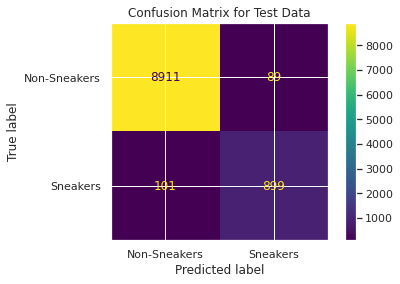

In [36]:
probability_threshold = 0.5

predictions = model_tf.predict(x=X_test) > probability_threshold
cm = confusion_matrix(Y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=["Non-Sneakers", "Sneakers"])
disp.plot()
plt.title("Confusion Matrix for Test Data")
plt.show()

In [37]:
print("1.")
true_positives = cm[1][1]
true_negatives = cm[0][0]
false_positives = cm[0][1]
false_negatives = cm[1][0]

print(f"True Positives: {true_positives}")
print(f"True Negatives: {true_negatives}")
print(f"False Positives: {false_positives}")
print(f"False Negatives: {false_negatives}")

1.
True Positives: 899
True Negatives: 8911
False Positives: 89
False Negatives: 101


In [38]:
print("2. Subgroup Accuracy for Test Data")
sneaker_accuracy = true_positives / (true_positives + false_negatives)
non_sneaker_accuracy = true_negatives / (true_negatives + false_positives)
print(f"Test Sneaker Accuracy = {sneaker_accuracy}")
print(f"Test Non-Sneaker Accuracy = {non_sneaker_accuracy}")

accuracy_difference = sneaker_accuracy - non_sneaker_accuracy
print(f"Test Difference in accuracy: {abs(accuracy_difference)}")

2. Subgroup Accuracy for Test Data
Test Sneaker Accuracy = 0.899
Test Non-Sneaker Accuracy = 0.9901111111111112
Test Difference in accuracy: 0.09111111111111114


**Answer 2**

The non-sneaker prediction is more accurate with 99% correct predictions compared to 90% correct predictions for the sneaker class. The model sees 4,800 sneakers and 43,200 non-sneakers in Y_train_mini. The data imbalance likely causes the model to learn non-sneaker features better, explaining the higher accuracy for that class.

 167/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 914us/step

2026-02-08 12:31:19.356056: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 150528000 exceeds 10% of free system memory.


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 882us/step


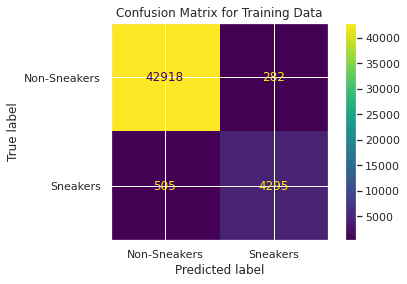

In [39]:
train_predictions = model_tf.predict(x=X_train_mini) > probability_threshold
train_cm = confusion_matrix(Y_train_mini, train_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=train_cm, 
                               display_labels=["Non-Sneakers", "Sneakers"])
disp.plot()
plt.title("Confusion Matrix for Training Data")
plt.show()

In [40]:
train_true_positives = train_cm[1][1]
train_true_negatives = train_cm[0][0]
train_false_positives = train_cm[0][1]
train_false_negatives = train_cm[1][0]
train_sneaker_accuracy = train_true_positives / (train_true_positives + train_false_negatives)
train_non_sneaker_accuracy = train_true_negatives / (train_true_negatives + train_false_positives)
print("3. Subgroup Accuracy for Train Data")
print(f"Training Sneaker Accuracy = {train_sneaker_accuracy}")
print(f"Training Non-Sneaker Accuracy = {train_non_sneaker_accuracy}")

train_accuracy_difference = train_sneaker_accuracy - train_non_sneaker_accuracy
print(f"Training Difference in accuracy: {abs(train_accuracy_difference)}")

3. Subgroup Accuracy for Train Data
Training Sneaker Accuracy = 0.8947916666666667
Training Non-Sneaker Accuracy = 0.9934722222222222
Training Difference in accuracy: 0.09868055555555555


**Answer 3**

The subgroup accuracy of the model using the training data is nearly identical to the performance with test data. Sneaker accuracy was 89.5% for training and 89.9% for test. Non-sneaker accuracy was 99.3% for training and 99.0% for test. This model generalizes well to unseen data, and even performed slightly better on the test set than on the training set for the sneaker class.

----
### <span style="color:chocolate"></span> Additional practice (not graded)

Is it possible to enhance the prediction accuracy for the sneaker class by performing the following steps?

1. Implement data balancing techniques, such as oversampling or undersampling, to equalize the representation of both classes.
2. After balancing the data, retrain the model on the balanced dataset.
3. Evaluate the model's performance, particularly focusing on the accuracy achieved for the sneaker class.


<span style="color:chocolate">Note: upload a separate notebook in Gradescope for this question.</span>